# OEM EDGAR To ICON R2B5 Example

This notebook demonstrates the ARTist OEM workflow using EDGAR 2020 emissions for `CH4` and `CO2`, mapped to the public ICON R2B5 grid. It includes Cartopy plots for both raw EDGAR data and mapped ICON-grid emissions.

In [37]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import xarray as xr

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import artist
from artist.oem import DEFAULT_ICON_GRID_URL

## Configuration

The example uses a small species list but keeps the full R2B5 grid. The first execution downloads the public ICON grid, EDGAR files, and creates reusable remapping weights.

In [2]:
YEAR = 2020
SPECIES = ["CH4", "CO2"]

workdir = Path("examples/oem_2020_r2b5")
edgar_directory = workdir / "edgar"
output_dir = workdir / "output"
gridfile = workdir / "icon_grid_0030_R02B05_G.nc"
weights_file = workdir / "r2b5_remap_weights.nc"

for directory in (workdir, edgar_directory, output_dir):
    directory.mkdir(parents=True, exist_ok=True)

YEAR, SPECIES, gridfile

(2020,
 ['CH4', 'CO2'],
 WindowsPath('examples/oem_2020_r2b5/icon_grid_0030_R02B05_G.nc'))

## Prepare The R2B5 ICON Grid

`ds.icon.add_grid(...)` stores the grid path on the dataset, so OEM methods can reuse it without passing `gridfile` repeatedly.

In [3]:
if not gridfile.exists():
    import urllib.request

    urllib.request.urlretrieve(DEFAULT_ICON_GRID_URL, gridfile)

ds = xr.Dataset()
grid = ds.icon.add_grid(gridfile, ltranslon=False)
grid.close()

print("Grid:", gridfile)
print("Cells:", ds.sizes.get("ncells"))
print("Remembered gridfile:", ds.attrs.get("_artist_gridfile"))

Grid: examples\oem_2020_r2b5\icon_grid_0030_R02B05_G.nc
Cells: None
Remembered gridfile: examples\oem_2020_r2b5\icon_grid_0030_R02B05_G.nc


## Map EDGAR 2020 Emissions To ICON

This cell downloads EDGAR files for the selected species if they are not already present, remaps them to ICON R2B5, writes OEM input files to `output_dir`, and returns the gridded emissions dataset.

In [4]:
emissions = ds.oem.map_edgar(
    edgar_directory=edgar_directory,
    year=YEAR,
    species=SPECIES,
    output_dir=output_dir,
    download=True,
    weights_file=weights_file,
    open_output=True,
)

emissions

Downloaded 39 files.


<xarray.Dataset> Size: 78MB
Dimensions:                        (cell: 81920, nv: 3, vertex: 40962, ne: 6,
                                    edge: 122880, no: 4, nc: 2,
                                    vert_delaunay: 3, cell_delaunay: 163836,
                                    region: 381)
Coordinates:
    clon                           (cell) float64 655kB ...
    clat                           (cell) float64 655kB ...
    vlon                           (vertex) float64 328kB ...
    vlat                           (vertex) float64 328kB ...
    elon                           (edge) float64 983kB ...
    elat                           (edge) float64 983kB ...
Dimensions without coordinates: cell, nv, vertex, ne, edge, no, nc,
                                vert_delaunay, cell_delaunay, region
Data variables: (12/87)
    clon_vertices                  (cell, nv) float64 2MB ...
    clat_vertices                  (cell, nv) float64 2MB ...
    vlon_vertices                  (vertex, ne) float64 2MB ...
    vlat_vertices                  (vertex, ne) float64 2MB ...
    elon_vertices                  (edge, no) float64 4MB ...
    elat_vertices                  (edge, no) float64 4MB ...
    ...                             ...
    TRO-CO2                        (cell) float64 655kB ...
    country_ids                    (cell) int64 655kB ...
    timezone_of_country            (region) <U30 46kB ...
    temporal_profile_id            (region) int32 2kB ...
    region_identifier              (region) <U32 49kB ...
    tz_shift                       (region) int32 2kB ...
Attributes: (12/21)
    title:                ICON grid description
    history:              /panfs/e/vol2/gzaengl/icon-dev/build/x86_64-unknown...
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    source:               icon-dev
    uuidOfHGrid:          a668eac0-fe2e-11e4-9a47-e3e5371a87a7
    number_of_grid_used:  30
    ...                   ...
    inverse_flattening:   0.0
    grid_level:           5
    grid_root:            2
    grid_ID:              1
    parent_grid_ID:       0
    max_childdom:         1

## Raw EDGAR Plots

Raw EDGAR fields are plotted before remapping. The `coarsen` argument keeps the global plot responsive while preserving the broad spatial pattern.

C:\Users\cb4150\AppData\Local\anaconda3\lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


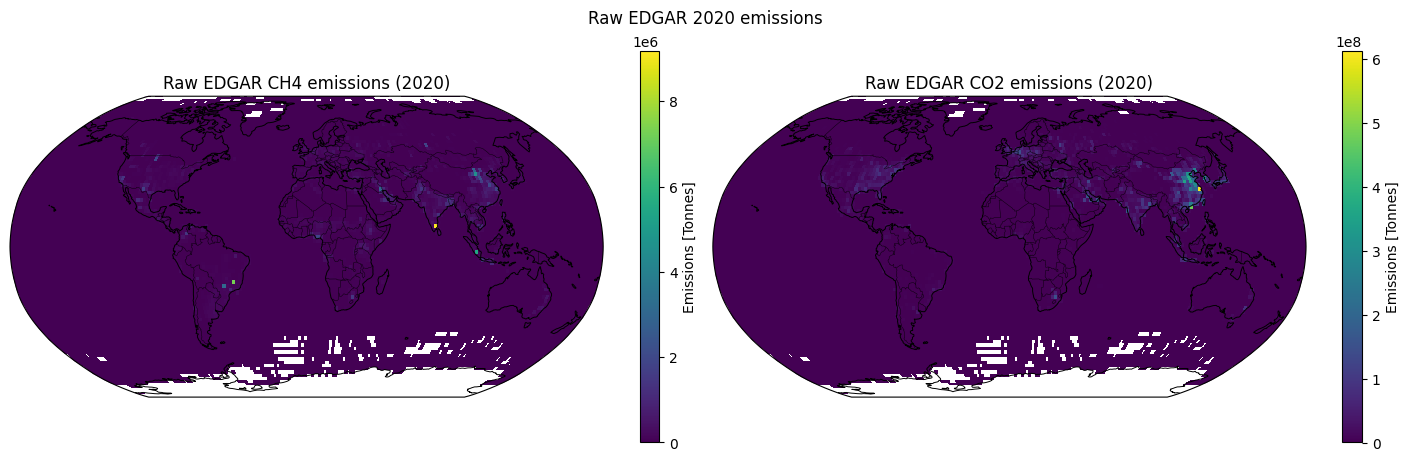

In [5]:
projection = ccrs.Robinson()
fig, axes = plt.subplots(
    1,
    len(SPECIES),
    figsize=(14, 4.5),
    subplot_kw={"projection": projection},
    constrained_layout=True,
)

raw_axes = ds.oem.plot_raw_edgar(
    edgar_directory=edgar_directory,
    year=YEAR,
    species=SPECIES,
    ax=axes,
    coarsen=20,
    cmap="viridis",
    transform=ccrs.PlateCarree(),
)

for ax in axes:
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_global()

fig.suptitle(f"Raw EDGAR {YEAR} emissions")
plt.show()

## Mapped ICON R2B5 Plots

The mapped data are drawn on native ICON polygons. ARTist reads the vertex coordinates from the R2B5 grid attached above and transforms them through Cartopy.

In [36]:
spc = emissions.icon.look_up('CH4')
spc

['AGS-CH4',
 'AWB-CH4',
 'CHE-CH4',
 'ENE-CH4',
 'ENF-CH4',
 'IND-CH4',
 'IRO-CH4',
 'MNM-CH4',
 'PRO_FFF-CH4',
 'RCO-CH4',
 'REF_TRF-CH4',
 'SWD_INC-CH4',
 'SWD_LDF-CH4',
 'TNR_Aviation_CDS-CH4',
 'TNR_Aviation_CRS-CH4',
 'TNR_Aviation_LTO-CH4',
 'TNR_Other-CH4',
 'TNR_Ship-CH4',
 'TRO-CH4',
 'WWT-CH4']

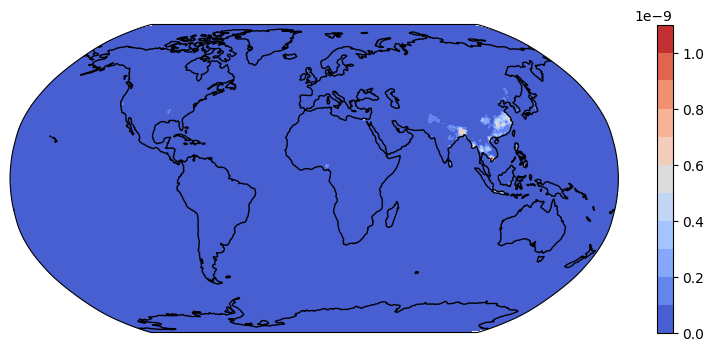

<GeoAxes: >

In [29]:
emissions.icon.add_grid(gridfile, ltranslon=False)
emissions['AGS-CH4'].art.quick_plot()

## Output Files

The gridded emission file is returned above. Temporal and vertical OEM profile files are written in the same output directory.

In [8]:
sorted(path.name for path in output_dir.iterdir())

['.emiproc_tz_mask_icon_grid_0030_R02B05_G.npy',
 'dayofweek.nc',
 'hourofday.nc',
 'monthofyear.nc',
 'oem_gridded_emissions.nc',
 'vertical_profiles.nc']